analyte  act>volta   median Δ(a−v)  Wilcoxon p
DA            5/7           0.031      0.4688
5HT           6/7           0.150      0.0469
NE            3/7          -0.011      0.9375
saved


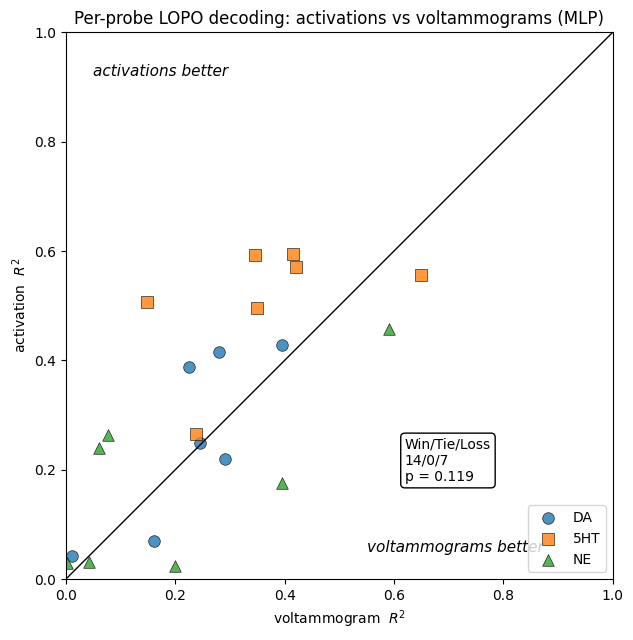

In [2]:
import torch, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, pearsonr

COLS = ['DA', '5HT', 'NE', 'pH']; MONO = ['DA', '5HT', 'NE']
v = torch.load('volta_train/lopo_volta.pt', weights_only=False)
a = torch.load('act_train/lopo_act.pt',   weights_only=False)
assert np.array_equal(v['probes'], a['probes']), "probe order mismatch — not paired!"
probes = v['probes']

def per_probe_r2c(res):
    t, p, pr = res['tgts_nM'].numpy(), res['preds_nM'].numpy(), res['probe_of_row']
    out = {c: [] for c in MONO}
    for c in MONO:
        j = COLS.index(c)
        for probe in probes:
            m = pr == probe
            out[c].append(pearsonr(t[m, j], p[m, j])[0] ** 2 if m.sum() > 2 else np.nan)
        out[c] = np.array(out[c])
    return out

V, A = per_probe_r2c(v), per_probe_r2c(a)

print(f"{'analyte':6}{'act>volta':>11}{'median Δ(a−v)':>16}{'Wilcoxon p':>12}")
for c in MONO:
    dv = A[c] - V[c]
    valid = ~np.isnan(dv); d = dv[valid]
    wins = int((d > 0).sum())
    try:    p = wilcoxon(d, alternative='two-sided').pvalue
    except: p = np.nan                    # all-zero diffs
    print(f"{c:6}{f'{wins}/{len(d)}':>11}{np.median(d):16.3f}{p:12.4f}")

# scatter in the Ismail-Fawaz format: one point per probe per analyte
fig, ax = plt.subplots(figsize=(6.5, 6.5))
mk = {'DA': 'o', '5HT': 's', 'NE': '^'}
for c in MONO:
    ax.scatter(V[c], A[c], marker=mk[c], s=70, label=c, alpha=0.8, edgecolor='k', lw=0.5)
ax.plot([0, 1], [0, 1], 'k-', lw=1)
ax.text(0.05, 0.92, 'activations better', fontsize=11, style='italic')
ax.text(0.55, 0.05, 'voltammograms better', fontsize=11, style='italic')
alld = np.concatenate([A[c] - V[c] for c in MONO]); allv = ~np.isnan(alld)
W = int((alld[allv] > 0).sum()); L = int((alld[allv] < 0).sum()); T = int((alld[allv] == 0).sum())
pall = wilcoxon(alld[allv], alternative='two-sided').pvalue
ax.text(0.62, 0.18, f'Win/Tie/Loss\n{W}/{T}/{L}\np = {pall:.3f}',
        bbox=dict(boxstyle='round', fc='white', ec='k'), fontsize=10)
ax.set_xlabel('voltammogram  $R^2$'); ax.set_ylabel('activation  $R^2$')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.legend(loc='lower right')
ax.set_title('Per-probe LOPO decoding: activations vs voltammograms (MLP)')
fig.tight_layout(); fig.savefig('lopo_paired_test.png', dpi=150); print('saved')